In [1]:
import sys
print(sys.executable)
# install into the kernel
# python -m pip install pandas
# python -m pip install -U matplotlib
# python -m pip install scipy
# python -m pip install seaborn

/usr/local/Cellar/jupyterlab/4.0.9_2/libexec/bin/python


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

df = pd.read_csv('Szabi/2023.12.27.Szabi_36strokesPerMinute_wrongRate_trajectory.csv')
df = df.rename(columns={'Handle/0/X':'Handle_X', 'Handle/0/Y':'Handle_Y', 'Shoulder/0/X':'Shoulder_X', 'Shoulder/0/Y':'Shoulder_Y', 'Seat/0/X':'Seat_X'})
df = df.drop(columns=['Time', 'Seat/0/Y'])
df.insert(0, 'Index', range(0, len(df)))
df = df.set_index('Index')
# df.head()

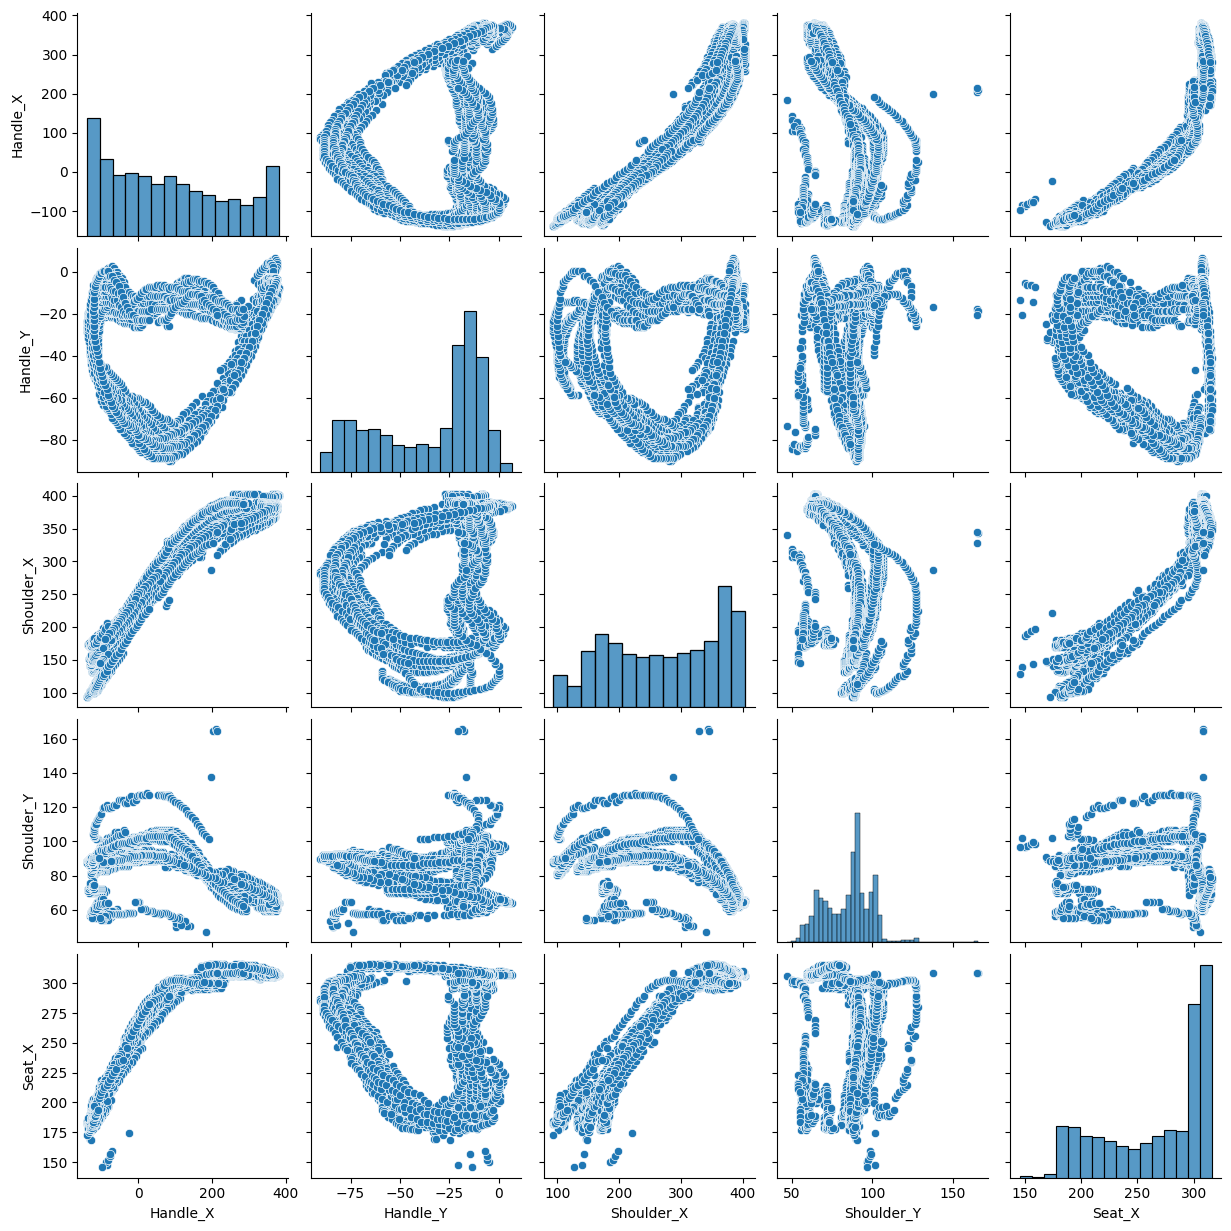

In [3]:
sns.pairplot(df)
plt.show()

In [4]:
# smoothing the data
df['Handle_X_Smooth'] = df['Handle_X'].rolling(10).mean()
df['Handle_Y_Smooth'] = df['Handle_Y'].rolling(10).mean()
df['Shoulder_X_Smooth'] = df['Shoulder_X'].rolling(10).mean()
df['Shoulder_Y_Smooth'] = df['Shoulder_Y'].rolling(10).mean()
df['Seat_X_Smooth'] = df['Seat_X'].rolling(10).mean()

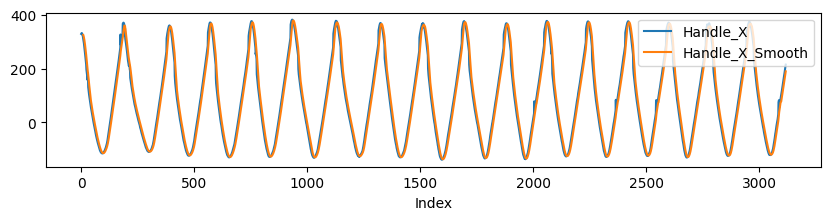

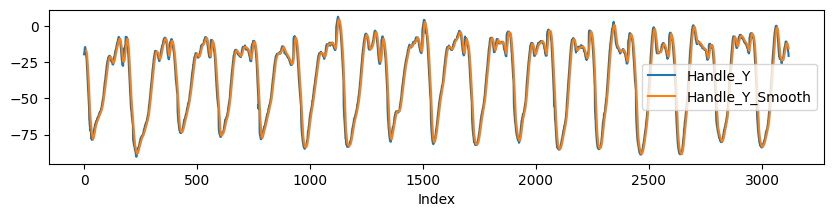

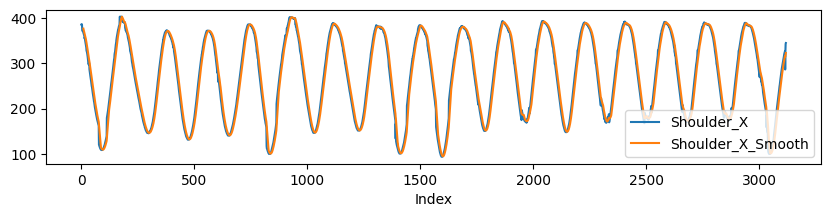

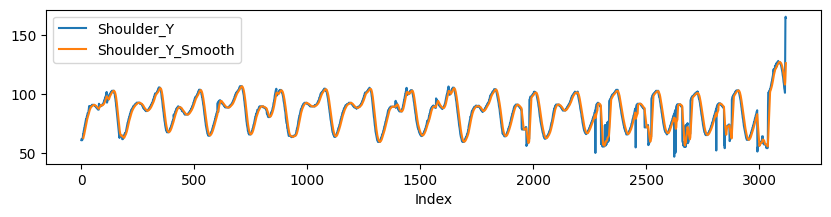

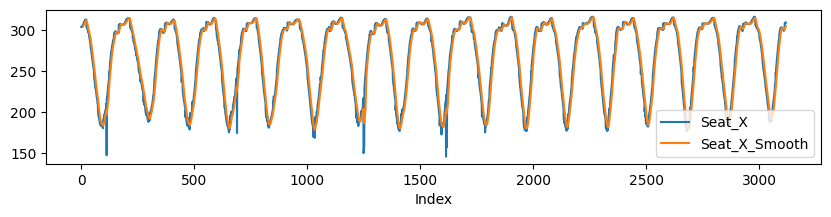

In [5]:
df.plot(y=['Handle_X', 'Handle_X_Smooth'], figsize=(10, 2))
df.plot(y=['Handle_Y', 'Handle_Y_Smooth'], figsize=(10, 2))
df.plot(y=['Shoulder_X', 'Shoulder_X_Smooth'], figsize=(10, 2))
df.plot(y=['Shoulder_Y', 'Shoulder_Y_Smooth'], figsize=(10, 2))
df.plot(y=['Seat_X', 'Seat_X_Smooth'], figsize=(10, 2))
plt.show()

In [6]:
def debugStrokeStart(window):
    current = window.iloc[1]
    currentIndex = window.index[1]
    prev = window.iloc[0]
    prevIndex = window.index[0]

    if currentIndex > 950 and currentIndex < 1010:
        print(window)
    
    if prev > 100 and current <= 100:
        return 100
    else:
        return 0

def markStrokeStart(window):
    current = window[1]
    prev = window[0]
    
    if prev > 100 and current <= 100:
        return 100
    else:
        return 0

# mark when handle is roughly at straight hands, hands away as this is the point where the stroke cycle starts
# df['Handle_X_Smooth'].rolling(2).apply(debugStrokeStart)
df['Stroke_Start'] = df['Handle_X_Smooth'].rolling(2).apply(markStrokeStart, raw=True)

In [7]:
# remove partial stroke cycles
stroke_starts = df.loc[df['Stroke_Start'] == 100]
print(stroke_starts.index)
first_index = stroke_starts.index[0]
last_index = stroke_starts.index[-1] - 3 # delete before new cycle starts
df = df.drop(df.index[0:first_index])
df = df.drop(df.index[last_index:df.index[-1]])

Index([  40,  234,  427,  608,  792,  980, 1173, 1368, 1552, 1738, 1921, 2101,
       2281, 2461, 2640, 2816, 3000],
      dtype='int64', name='Index')


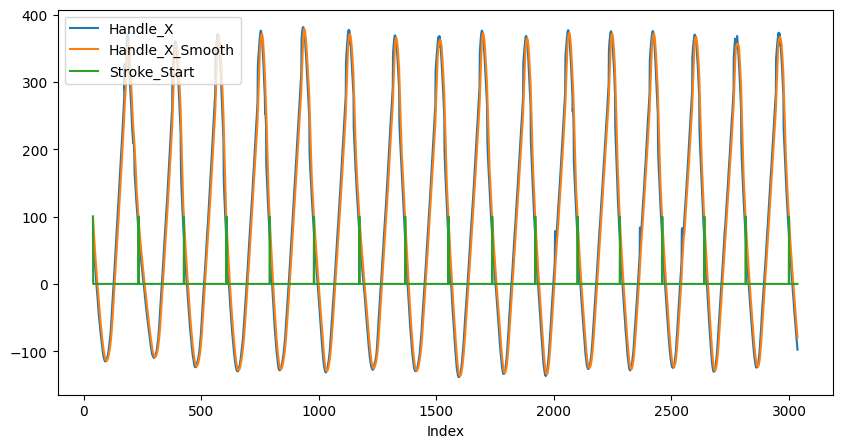

In [8]:
df.plot(y=['Handle_X', 'Handle_X_Smooth', 'Stroke_Start'], figsize=(10, 5))
plt.show()

In [9]:
df = df.drop(columns=['Handle_X', 'Handle_Y', 'Shoulder_X', 'Shoulder_Y', 'Seat_X'])

In [10]:
# split into cycles
start_index = stroke_starts.index[0]
cycles = []
for index in stroke_starts.index[1:]:
    cycle = df[start_index:index-1]
    cycles.append(cycle)
    start_index = index

for c in cycles:
  print(c.shape)

(193, 6)
(192, 6)
(180, 6)
(183, 6)
(187, 6)
(192, 6)
(194, 6)
(183, 6)
(185, 6)
(182, 6)
(179, 6)
(179, 6)
(179, 6)
(178, 6)
(175, 6)
(181, 6)


In [11]:
# add new index to make merge easier
for c in cycles:
    c.reset_index(drop=True, inplace=True)
    c.index.name = 'Cycle_Index'

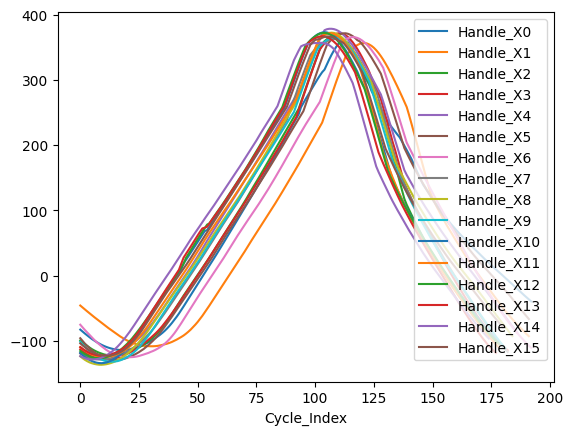

In [12]:
# verify the split was okay and the lines are roughly together
df_handles = pd.DataFrame()
for index, c in enumerate(cycles):
    df_handles['Handle_X' + str(index)] = c['Handle_X_Smooth']
df_handles.plot()
plt.show()

In [13]:
# merge the cycles into one average dataframe
df_avg = pd.concat(cycles).groupby('Cycle_Index', as_index=True).mean()

# drop Stroke_Start as it is not needed anymore
df_avg = df_avg.drop(columns=['Stroke_Start'])

In [14]:
# remove rows that are longer than minimum length, as the average value cannot be calculated properly and skews the data anyway
rows = []
for c in cycles:
    rows.append(c.shape[0])
shortest_row_count = min(rows)
print(shortest_row_count)
df_avg = df_avg[0:shortest_row_count]

175


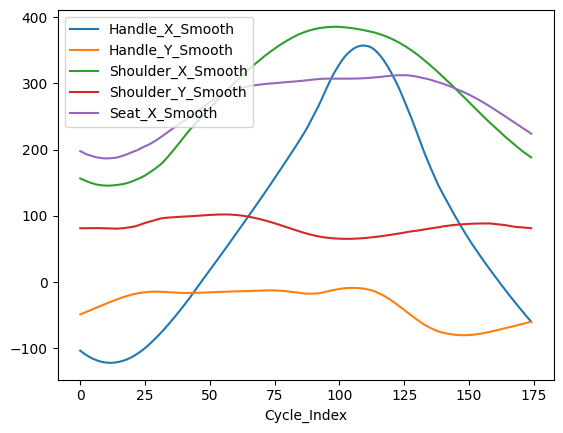

In [15]:
df_avg.plot()
plt.show()

In [16]:
# standardize, rescale the values
import scipy
from scipy import stats

df_avg['Handle_X_Smooth'] = stats.zscore(df_avg['Handle_X_Smooth'])
df_avg['Handle_Y_Smooth'] = stats.zscore(df_avg['Handle_Y_Smooth'])
df_avg['Shoulder_X_Smooth'] = stats.zscore(df_avg['Shoulder_X_Smooth'])
df_avg['Shoulder_Y_Smooth'] = stats.zscore(df_avg['Shoulder_Y_Smooth'])
df_avg['Seat_X_Smooth'] = stats.zscore(df_avg['Seat_X_Smooth'])

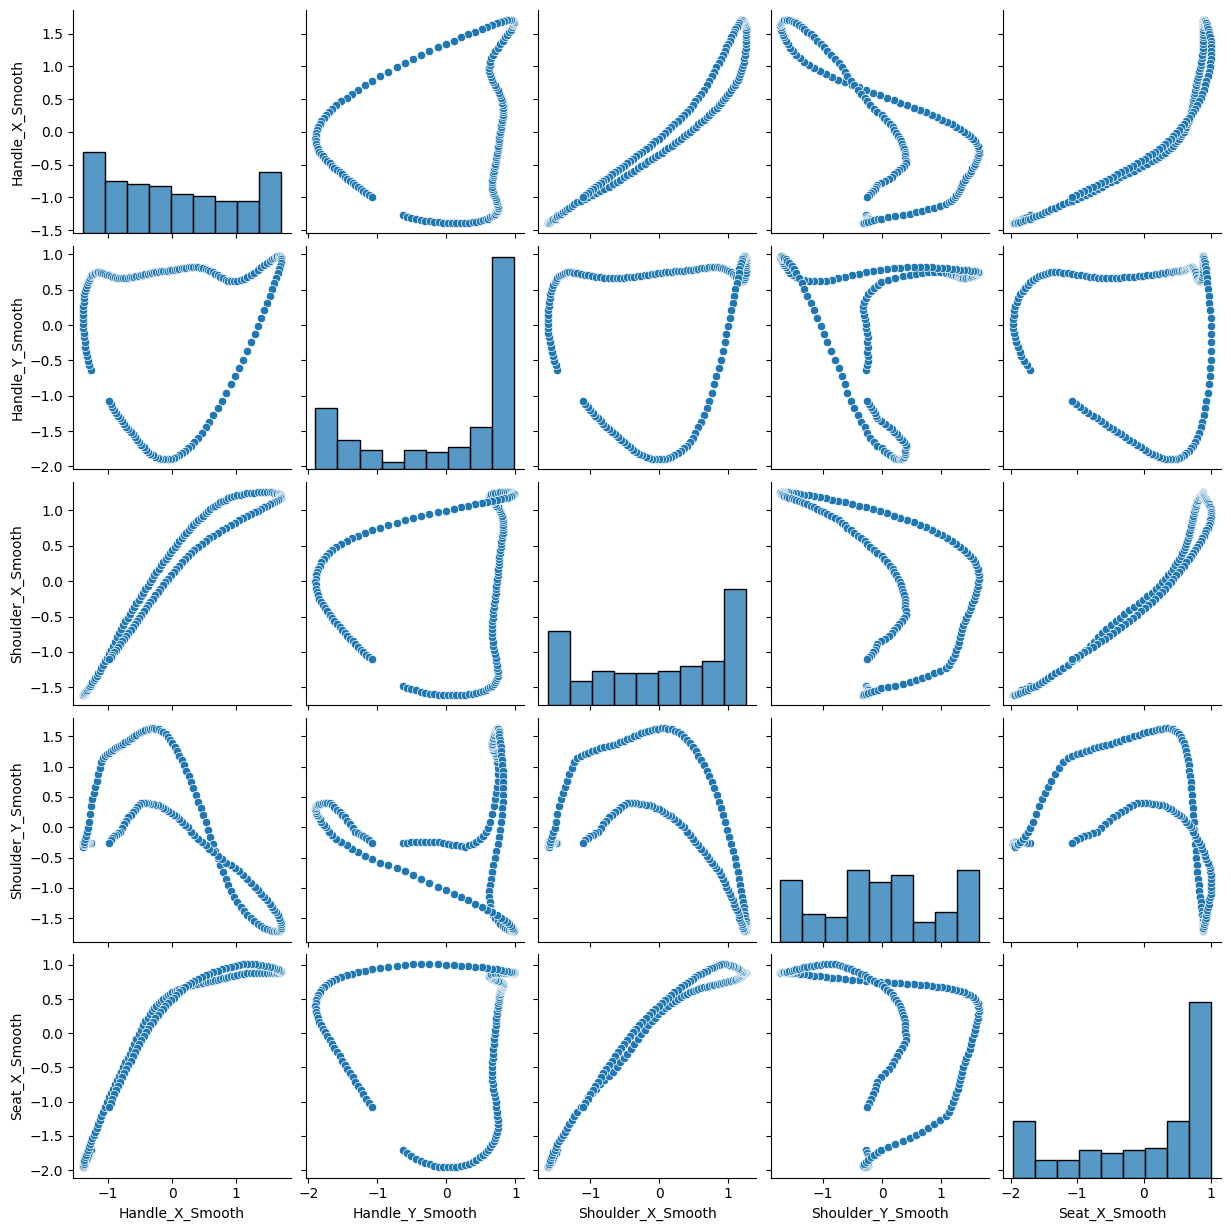

In [17]:
sns.pairplot(df_avg)
plt.show()

In [18]:
catch_index = 10
finish_index = 110

def plot(title, data):
    ax = data.plot(figsize=(10, 5))
    ax.axvline(catch_index, color='green', linestyle='dashed')
    plt.text(catch_index + 2, 1, 'Catch', rotation=90)
    ax.axvline(finish_index, color='green', linestyle='dashed')
    plt.text(finish_index + 2, -2, 'Finish', rotation=90)
    
    plt.title(title, color = 'red')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.show()

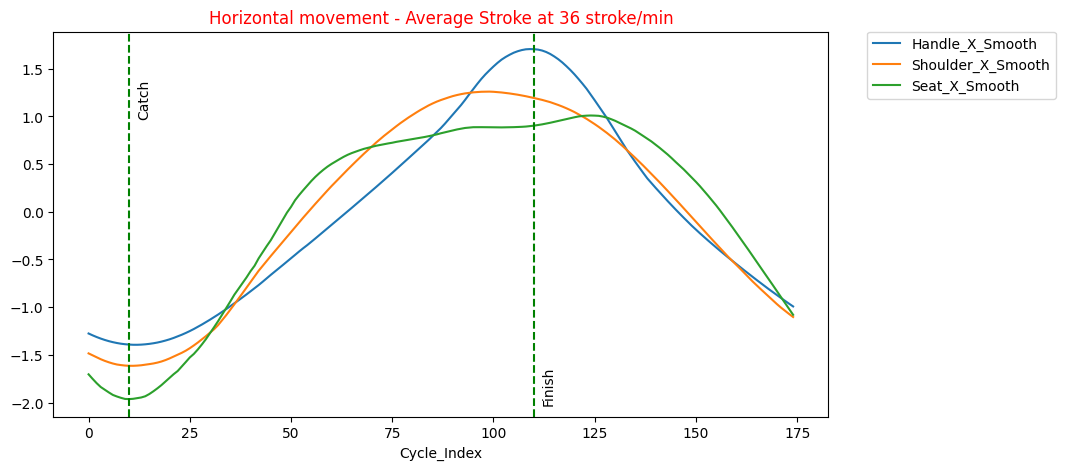

In [19]:
plot('Horizontal movement - Average Stroke at 36 stroke/min', df_avg[['Handle_X_Smooth', 'Shoulder_X_Smooth', 'Seat_X_Smooth']])

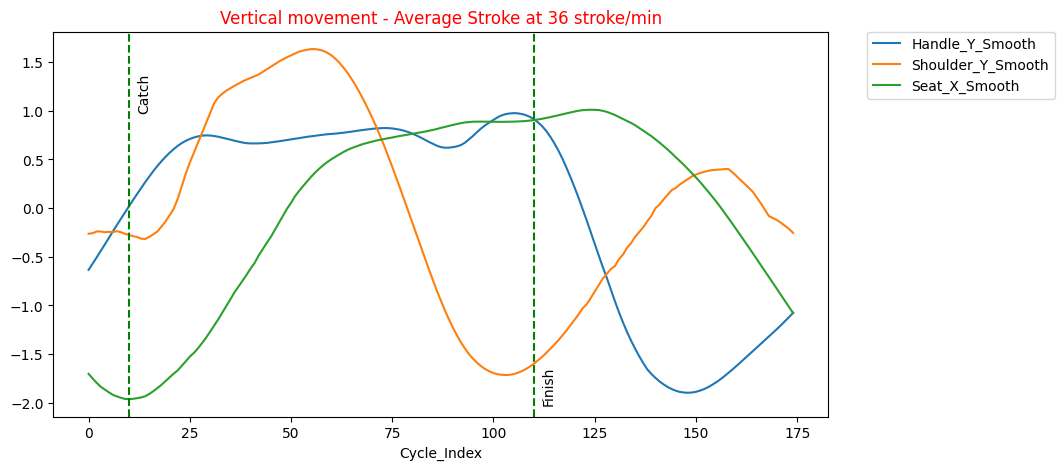

In [20]:
plot('Vertical movement - Average Stroke at 36 stroke/min', df_avg[['Handle_Y_Smooth', 'Shoulder_Y_Smooth', 'Seat_X_Smooth']])

In [21]:
# stroke ratio
drive_duration = finish_index - catch_index
recovery_duration = shortest_row_count - drive_duration
drive_percentage = (drive_duration / shortest_row_count) * 100
recovery_percentage = (recovery_duration / shortest_row_count) * 100
print(f'Averaged Drive / Recovery Ratio: {drive_percentage:2.0f} to {recovery_percentage:2.0f}')
print(f'   Ideal Drive / Recovery Ratio: 33 to 66')

Averaged Drive / Recovery Ratio: 57 to 43
   Ideal Drive / Recovery Ratio: 33 to 66


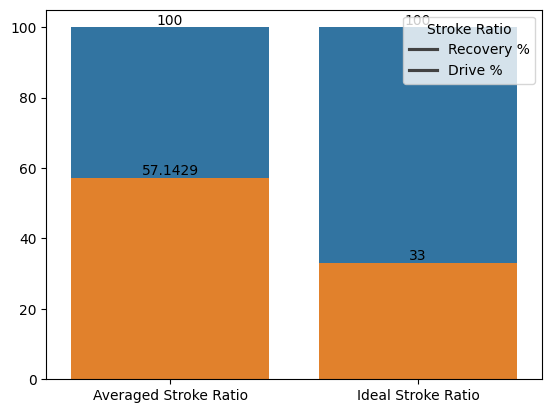

In [22]:
sns.barplot(data=[100, 100])
bar = sns.barplot(data=[drive_percentage, 33])
bar.set_xticks(range(2))
bar.set_xticklabels(['Averaged Stroke Ratio', 'Ideal Stroke Ratio'])
for i in bar.containers:
    bar.bar_label(i,)
plt.legend(title='Stroke Ratio', loc='upper right', labels=['Recovery %', 'Drive %'], facecolor='w')
plt.show()

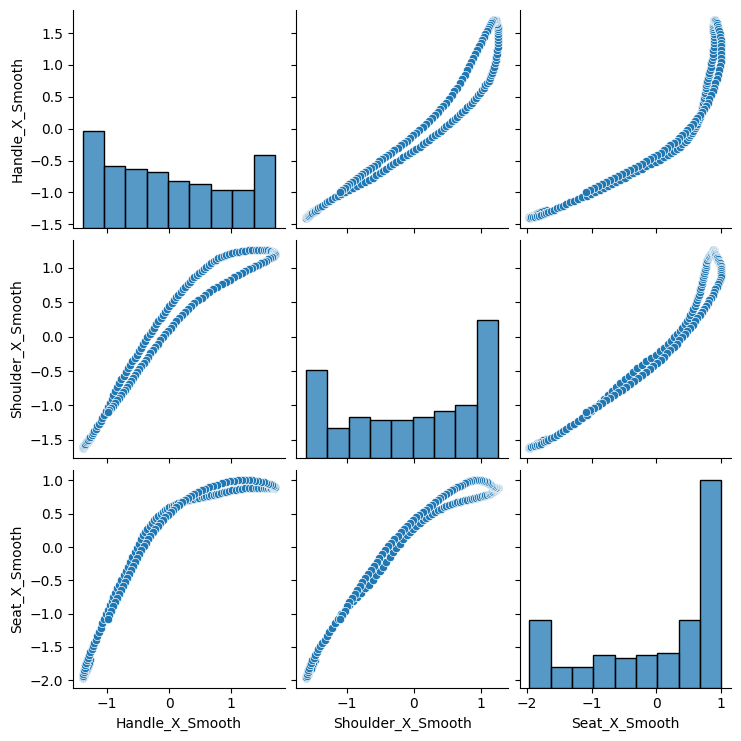

In [23]:
# correlation during stroke
sns.pairplot(df_avg[['Handle_X_Smooth', 'Shoulder_X_Smooth', 'Seat_X_Smooth']])
plt.show()

In [24]:
# Derivatives
# Caveat - smoothing pushes right the line potentially which gives misaligned lines
def derivate(column_name, derivative_column_name, smoothing, scaling):
    dy = np.diff(df_avg[column_name])
    dx = np.diff(df_avg.index)
    deriv = dy / dx
    # prepanding first element so the new data has the same dimension as the original
    df_avg[derivative_column_name] = np.insert(deriv, 0, deriv[0], axis=0)
    # smoothing the derivative
    df_avg[derivative_column_name] = df_avg[derivative_column_name].rolling(smoothing).mean()
    # back fill NaN so rescaling will work
    df_avg[derivative_column_name] = df_avg[derivative_column_name].bfill()
    # rescale the derivative
    df_avg[derivative_column_name] = stats.zscore(df_avg[derivative_column_name]) * scaling

In [25]:
derivate('Handle_X_Smooth', 'Handle_X_Velocity', 2, 1)
derivate('Handle_X_Velocity', 'Handle_X_Acceleration', 10, 0.5)
derivate('Handle_X_Acceleration', 'Handle_X_Jerk', 5, 0.2)

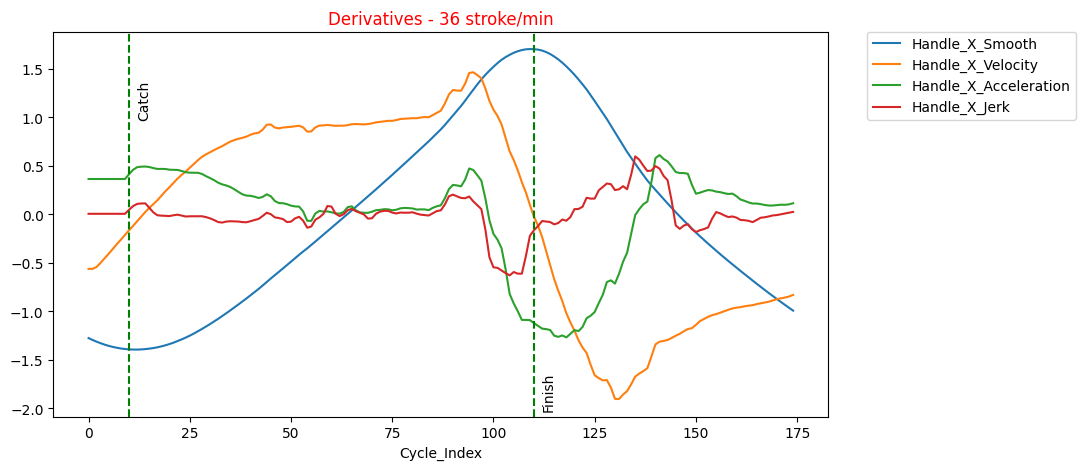

In [26]:
plot('Derivatives - 36 stroke/min', df_avg[['Handle_X_Smooth', 'Handle_X_Velocity', 'Handle_X_Acceleration', 'Handle_X_Jerk']])